# Feature Analysis: ACF and CCF for NVDA Intraday Volatility

**Author:** Ayooluwa Adelagun  
**Dataset:** NVDA Intraday Volatility Dataset

---

## Purpose

This notebook implements the feature analysis reported in **Chapter 5** of the dissertation, specifically Sections 5.2 (Autocorrelation Analysis) and 5.3 (Cross-Correlation Analysis) for the intraday dataset with the final five-feature input set.

Two analyses are conducted on the cleaned training data:

1. **ACF of Daily Volatility** (Section 5.2): tests whether the volatility series is autocorrelated with its own past values. Statistically significant positive autocorrelation out to lag 20 is the empirical signature of volatility clustering and motivates the use of recurrent architectures over feedforward models. This corresponds to **Figure 5.2** in the dissertation.

2. **CCF of each feature over Daily Volatility** (Section 5.3): tests whether past values of each feature carry statistically significant predictive information about future Daily Volatility at lags 1 to 20. Features exhibiting significant cross-correlation are retained in the model input set; this analysis also informs the sequence length choice of L = 15. This corresponds to **Figure 5.3** in the dissertation.

Both analyses are conducted on the training set only. Applying them to the full dataset would allow information from the test period to influence feature selection, constituting look-ahead bias.

## 1. Imports

`statsmodels` provides the `acf` and `ccf` functions used in Sections 5.2 and 5.3. The confidence bands in both plots are computed as $\pm 1.96 / \sqrt{n}$, corresponding to the 95% significance level used throughout Chapter 5.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)
from statsmodels.tsa.stattools import acf, ccf

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, SimpleRNN, LSTM, GRU, Dense, Dropout, Activation
)
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.16.2


## 2. Load Data

The intraday dataset with VIX is loaded. The five input features are: `Volume`, `Return`, `Return_Squared`, `Daily Volatility`, and `VIX`. The target distribution is printed to confirm the near 50/50 class balance documented in Table 3.10 of the dissertation.

In [2]:
data_full = pd.read_csv('NVDA_Intraday_Volatility_Dataset_VIX.csv', index_col='Date', parse_dates=True)

FEATURE_COLS = ['Volume', 'Return', 'Return_Squared', 'Daily Volatility', 'VIX']
TARGET_COL   = 'target'

print(f'Total rows:   {len(data_full):,}')
print(f'Date range:   {data_full.index.min().date()} to {data_full.index.max().date()}')
print(f'Columns:      {list(data_full.columns)}')
print(f'\nTarget distribution (full dataset):')
counts = data_full[TARGET_COL].value_counts()
for label in [0, 1]:
    print(f'  Class {label}: {counts[label]:,} ({counts[label]/len(data_full)*100:.1f}%)')
print(data_full[FEATURE_COLS + [TARGET_COL]].head())

Total rows:   5,323
Date range:   2005-01-03 to 2026-03-02
Columns:      ['Return_Squared', 'Return', 'Range', 'Volume', 'VIX', 'Daily Volatility', 'target']

Target distribution (full dataset):
  Class 0: 2,670 (50.2%)
  Class 1: 2,653 (49.8%)
                  Volume    Return  Return_Squared  Daily Volatility    VIX  \
Date                                                                          
2005-01-03  1.066716e+09  0.001018        0.000001          0.012517  14.08   
2005-01-04  7.902240e+08 -0.048485        0.002351          0.011489  13.98   
2005-01-05  7.248120e+08  0.009569        0.000092          0.013424  14.09   
2005-01-06  5.635680e+08 -0.009569        0.000092          0.007803  13.58   
2005-01-07  7.630920e+08 -0.019418        0.000377          0.012123  13.49   

            target  
Date                
2005-01-03       1  
2005-01-04       0  
2005-01-05       1  
2005-01-06       0  
2005-01-07       1  


## 3. Train-Test Split

The dataset is split chronologically at the 80% mark, identical to the split used in all model training notebooks. All feature analysis is conducted exclusively on the training portion so that no information from the test period influences feature selection or sequence length choice.

In [3]:
split_idx = int(len(data_full) * 0.8)

train_raw = data_full.iloc[:split_idx].copy()
test_raw  = data_full.iloc[split_idx:].copy()

print(f'Training rows: {len(train_raw):,}  ({train_raw.index.min().date()} to {train_raw.index.max().date()})')
print(f'Test rows:     {len(test_raw):,}   ({test_raw.index.min().date()} to {test_raw.index.max().date()})')

Training rows: 4,258  (2005-01-03 to 2021-11-30)
Test rows:     1,065   (2021-12-01 to 2026-03-02)


## 4. Outlier Removal

Outliers are removed from the **training set only** using a rolling median absolute deviation (MAD) approach with a centred window of 41 observations, as described in Section 3.7 of the dissertation. The ACF and CCF analyses are conducted on the cleaned training set so that correlation estimates are not distorted by extreme observations such as those from the 2008 financial crisis or the 2020 COVID dislocation.

In [ ]:
OUTLIER_THRESHOLD = 2
ROLLING_WINDOW    = 41

train_clean = train_raw.copy()

for col in FEATURE_COLS:
    rolling_median = train_clean[col].rolling(window=ROLLING_WINDOW, center=True, min_periods=1).median()
    abs_deviation  = (train_clean[col] - rolling_median).abs()
    mad            = abs_deviation.median()
    outlier_mask   = abs_deviation > OUTLIER_THRESHOLD * mad
    n_removed      = outlier_mask.sum()
    print(f'{col:<22}: {n_removed:,} rows removed ({n_removed/len(train_clean)*100:.1f}%)')
    train_clean = train_clean[~outlier_mask]

print(f'\nOriginal training rows: {len(train_raw):,}')
print(f'Cleaned training rows:  {len(train_clean):,}')
print(f'Total removed:          {len(train_raw) - len(train_clean):,} ({(len(train_raw)-len(train_clean))/len(train_raw)*100:.1f}%)')

Volume                : 244 rows removed (5.7%)
Return                : 98 rows removed (2.4%)
Return_Squared        : 557 rows removed (14.2%)
Daily Volatility      : 135 rows removed (4.0%)
VIX                   : 178 rows removed (5.5%)

Original training rows: 4,258
Cleaned training rows:  3,046
Total removed:          1,212 (28.5%)


## 5. Autocorrelation Analysis (Section 5.2)

The ACF of the Daily Volatility series is computed and plotted for lags 1 to 20. Bars are coloured blue if the autocorrelation coefficient exceeds the 95% confidence band $\pm 1.96 / \sqrt{n}$ and red otherwise, following the Ljung-Box significance framework described in Section 5.2.1.

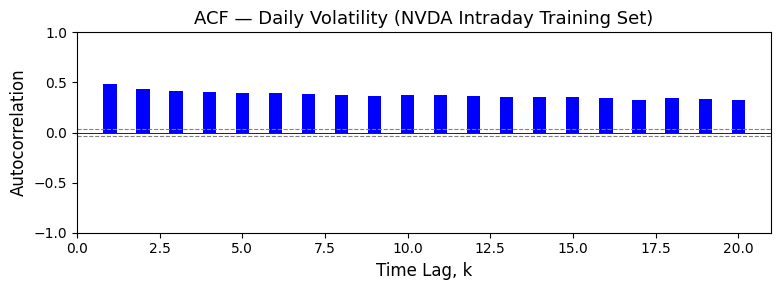

In [6]:
vol_series = train_clean['Daily Volatility'].values
n          = len(vol_series)
conf_band  = 1.96 / np.sqrt(n)
LAGS       = 20
lags_arr   = np.arange(1, LAGS + 1)

# ACF of Daily Volatility
acf_vals = acf(vol_series, nlags=LAGS, fft=True)
colors   = ['blue' if abs(acf_vals[k]) > conf_band else 'red' for k in lags_arr]

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(lags_arr, acf_vals[1:], color=colors, width=0.4)
ax.axhline(conf_band,  color='grey', linestyle='--', linewidth=0.8)
ax.axhline(-conf_band, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xlabel('Time Lag, k', fontsize=12)
ax.set_ylabel('Autocorrelation', fontsize=12)
ax.set_title('ACF — Daily Volatility (NVDA Intraday Training Set)', fontsize=13)
ax.set_xlim(0, LAGS + 1)
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.savefig('NVDA_ACF_DailyVolatility.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## 6. Cross-Correlation Analysis (Section 5.3)

The CCF of Daily Volatility over each of the five features is computed for lags 1 to 20. A positive CCF value at lag $k$ indicates that past values of the feature tend to be followed by above-average Daily Volatility $k$ days later, meaning the feature leads volatility.

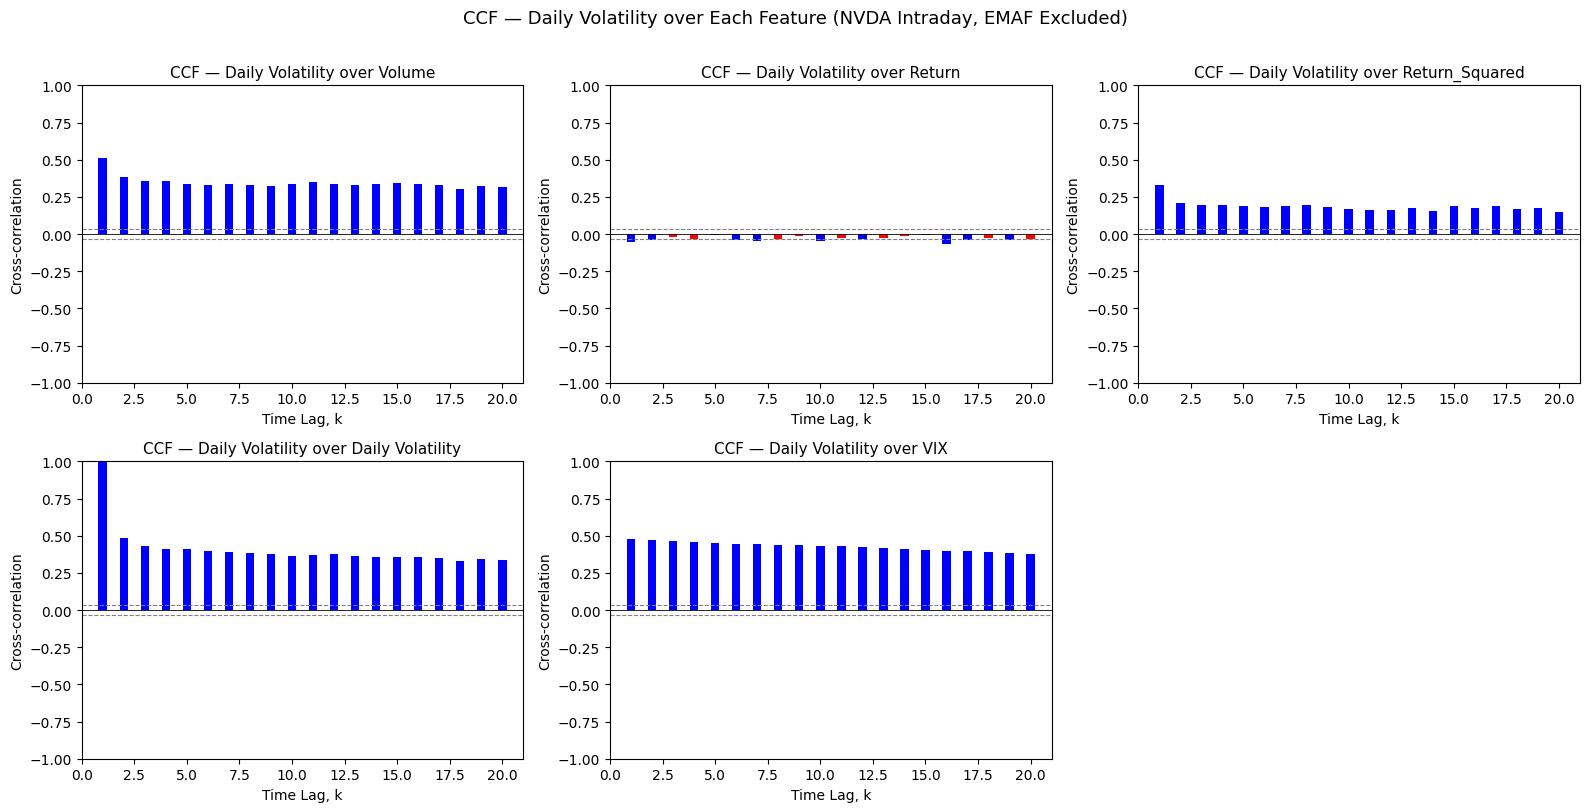

In [7]:
# CCF of each feature over Daily Volatility
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(FEATURE_COLS):
    feat_series = train_clean[col].values
    ccf_vals    = ccf(feat_series, vol_series, nlags=LAGS, unbiased=False)
    colors      = ['blue' if abs(ccf_vals[k]) > conf_band else 'red' for k in range(LAGS)]
    axes[idx].bar(lags_arr, ccf_vals[0:LAGS], color=colors, width=0.4)
    axes[idx].axhline(conf_band,  color='grey', linestyle='--', linewidth=0.8)
    axes[idx].axhline(-conf_band, color='grey', linestyle='--', linewidth=0.8)
    axes[idx].axhline(0, color='black', linewidth=0.6)
    axes[idx].set_title(f'CCF — Daily Volatility over {col}', fontsize=11)
    axes[idx].set_xlabel('Time Lag, k', fontsize=10)
    axes[idx].set_ylabel('Cross-correlation', fontsize=10)
    axes[idx].set_xlim(0, LAGS + 1)
    axes[idx].set_ylim(-1, 1)

axes[-1].set_visible(False)
plt.suptitle('CCF — Daily Volatility over Each Feature (NVDA Intraday Training Set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('NVDA_CCF_Features.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()